# Dataset Preparation

- input: curated briefsummary
- output: pd.series of ase objects pr pymatgen objects


In [1]:
import sys

In [2]:
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')

In [3]:
from BopFoxFeaturizer.Featurizer import Featurizer

/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/struct_db.py:95: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.df_struc = self.df_struc.append(
/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/struct_db.py:99: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.df_struc = self.df_struc.append(
/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/struct_db.py:103: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.df_struc = self.df_struc.append(
/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/struct_db.py:107: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.co

In [4]:
from GetAtomsObjects import * 

TODO: remove the loop and work only with one option !
TODO: use the curated dataset

In [5]:
case='POSCAR-initial' #, 'POSCAR-relaxed']
rescale_by_atoms=True #, False]
subcase = 'rescaled' # ,  'noscaled' ] 
Force= True
CuratedBS = 'CuratedParsedBriefSummary.pkl'

In [6]:
BS = pd.read_pickle(CuratedBS)

In [7]:
Features = Featurizer(BS)

chech that the chemistry resetting is correct!

In [8]:
#for thiscase, (thisrescale, thissubcase) in product(case, zip(rescale_by_atoms, subcase)):
database = '**/'+case
AtomsFile = 'CrCoW-sorted-'+case+'-'+subcase+'-AtomsObjects.pkl'
if not need_to_update(AtomsFile):  #os.path.exists(AtomsFile) and not Force:
    Atoms_Objects = pd.read_pickle(AtomsFile)
else:
    Atoms_Objects, CantMake_Atoms_Object = Features.get_atoms_object(database=database,rescale_by_atoms=True, reset_chemistry=True, file_filter = 'sorted')
    Atoms_Objects.to_pickle(AtomsFile)
Atoms_Objects.dropna(inplace=True)
pymatgenfile = AtomsFile.replace('AtomsObjects','PymatgenStructures')
Pymatgen_Structures = Atoms_Objects.copy()
if not need_to_update(pymatgenfile):
    Pymatgen_Structures = pd.read_pickle(pymatgenfile)
else:
    Pymatgen_Structures = Atoms_Objects['atoms'].apply(AseAtomsAdaptor.get_structure)
    Pymatgen_Structures['file'] = Atoms_Objects['file']
    Pymatgen_Structures.to_pickle(pymatgenfile)

In [9]:
accomodatewrap = Atoms_Objects.atoms.map(lambda a: a.wrap(pretty_translation=True))

In [10]:
Atoms_Objects['atoms']

Co_pv6W_sv6.C14-BBA.NM                (Atom('Co', [2.2140135370609073, 1.27826074118...
Co_pv6W_sv6.C14-BBA.FM                (Atom('Co', [2.2140135370609073, 1.27826074118...
Cr_pv6W_sv2.D0_19-A3B.FM              (Atom('Cr', [-0.43112800154619224, 2.239330855...
Cr_pv6W_sv2.D0_19-A3B.NM              (Atom('Cr', [-0.43112800154619224, 2.239330855...
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM    (Atom('Cr', [5.541226311581246, 2.693413408415...
                                                            ...                        
Cr_pv10W_sv3.mu-BAAAB.FM              (Atom('Cr', [0.17444091391996086, 1.3746733531...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM     (Atom('Cr', [5.007611988807291, 5.007611988807...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM     (Atom('Cr', [5.007611988807291, 5.007611988807...
Co_pv13W_sv16.chi-ABAB.NM             (Atom('Co', [1.657374720890617, 1.657374720890...
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.NM    (Atom('Cr', [5.541226311581246, 2.693413408415...
Name: atoms, Length: 1663, dtype

In [13]:
Atoms_Objects[Atoms_Objects.atoms.isna()==True]

,atoms,file


In [14]:
Atoms_Objects

,atoms,file
Co_pv6W_sv6.C14-BBA.NM,"(Atom('Co', [2.2140135370609073, 1.27826074118...",[Co_pv-W_sv/POSCAR-initial/C14-BBA/relax/xc=PB...
Co_pv6W_sv6.C14-BBA.FM,"(Atom('Co', [2.2140135370609073, 1.27826074118...",[Co_pv-W_sv/POSCAR-initial/C14-BBA.FM/relax/xc...
Cr_pv6W_sv2.D0_19-A3B.FM,"(Atom('Cr', [-0.43112800154619224, 2.239330855...",[Cr_pv-W_sv/POSCAR-initial/D0_19-A3B.FM/relax/...
Cr_pv6W_sv2.D0_19-A3B.NM,"(Atom('Cr', [-0.43112800154619224, 2.239330855...",[Cr_pv-W_sv/POSCAR-initial/D0_19-A3B/relax/xc=...
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,"(Atom('Cr', [5.541226311581246, 2.693413408415...",[Cr_pv-Co_pv-W_sv/POSCAR-initial/sigma-CBAAC.F...
...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,"(Atom('Cr', [0.17444091391996086, 1.3746733531...",[Cr_pv-W_sv/POSCAR-initial/mu-BAAAB.FM/relax/x...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,"(Atom('Cr', [5.007611988807291, 5.007611988807...",[Cr_pv-Co_pv-W_sv/POSCAR-initial/sigma-BAACA.F...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,"(Atom('Cr', [5.007611988807291, 5.007611988807...",[Cr_pv-Co_pv-W_sv/POSCAR-initial/sigma-BAACA/r...
Co_pv13W_sv16.chi-ABAB.NM,"(Atom('Co', [1.657374720890617, 1.657374720890...",[Co_pv-W_sv/POSCAR-initial/chi-ABAB/relax/xc=P...


In [18]:
Pymatgen_Structures[Pymatgen_Structures.isna()==True]

Series([], Name: atoms, dtype: object)

#  visualization of some structures

In [19]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('axes.spines', bottom=False, top=False, right=False, left=False)

In [20]:
from ase.visualize.plot import plot_atoms

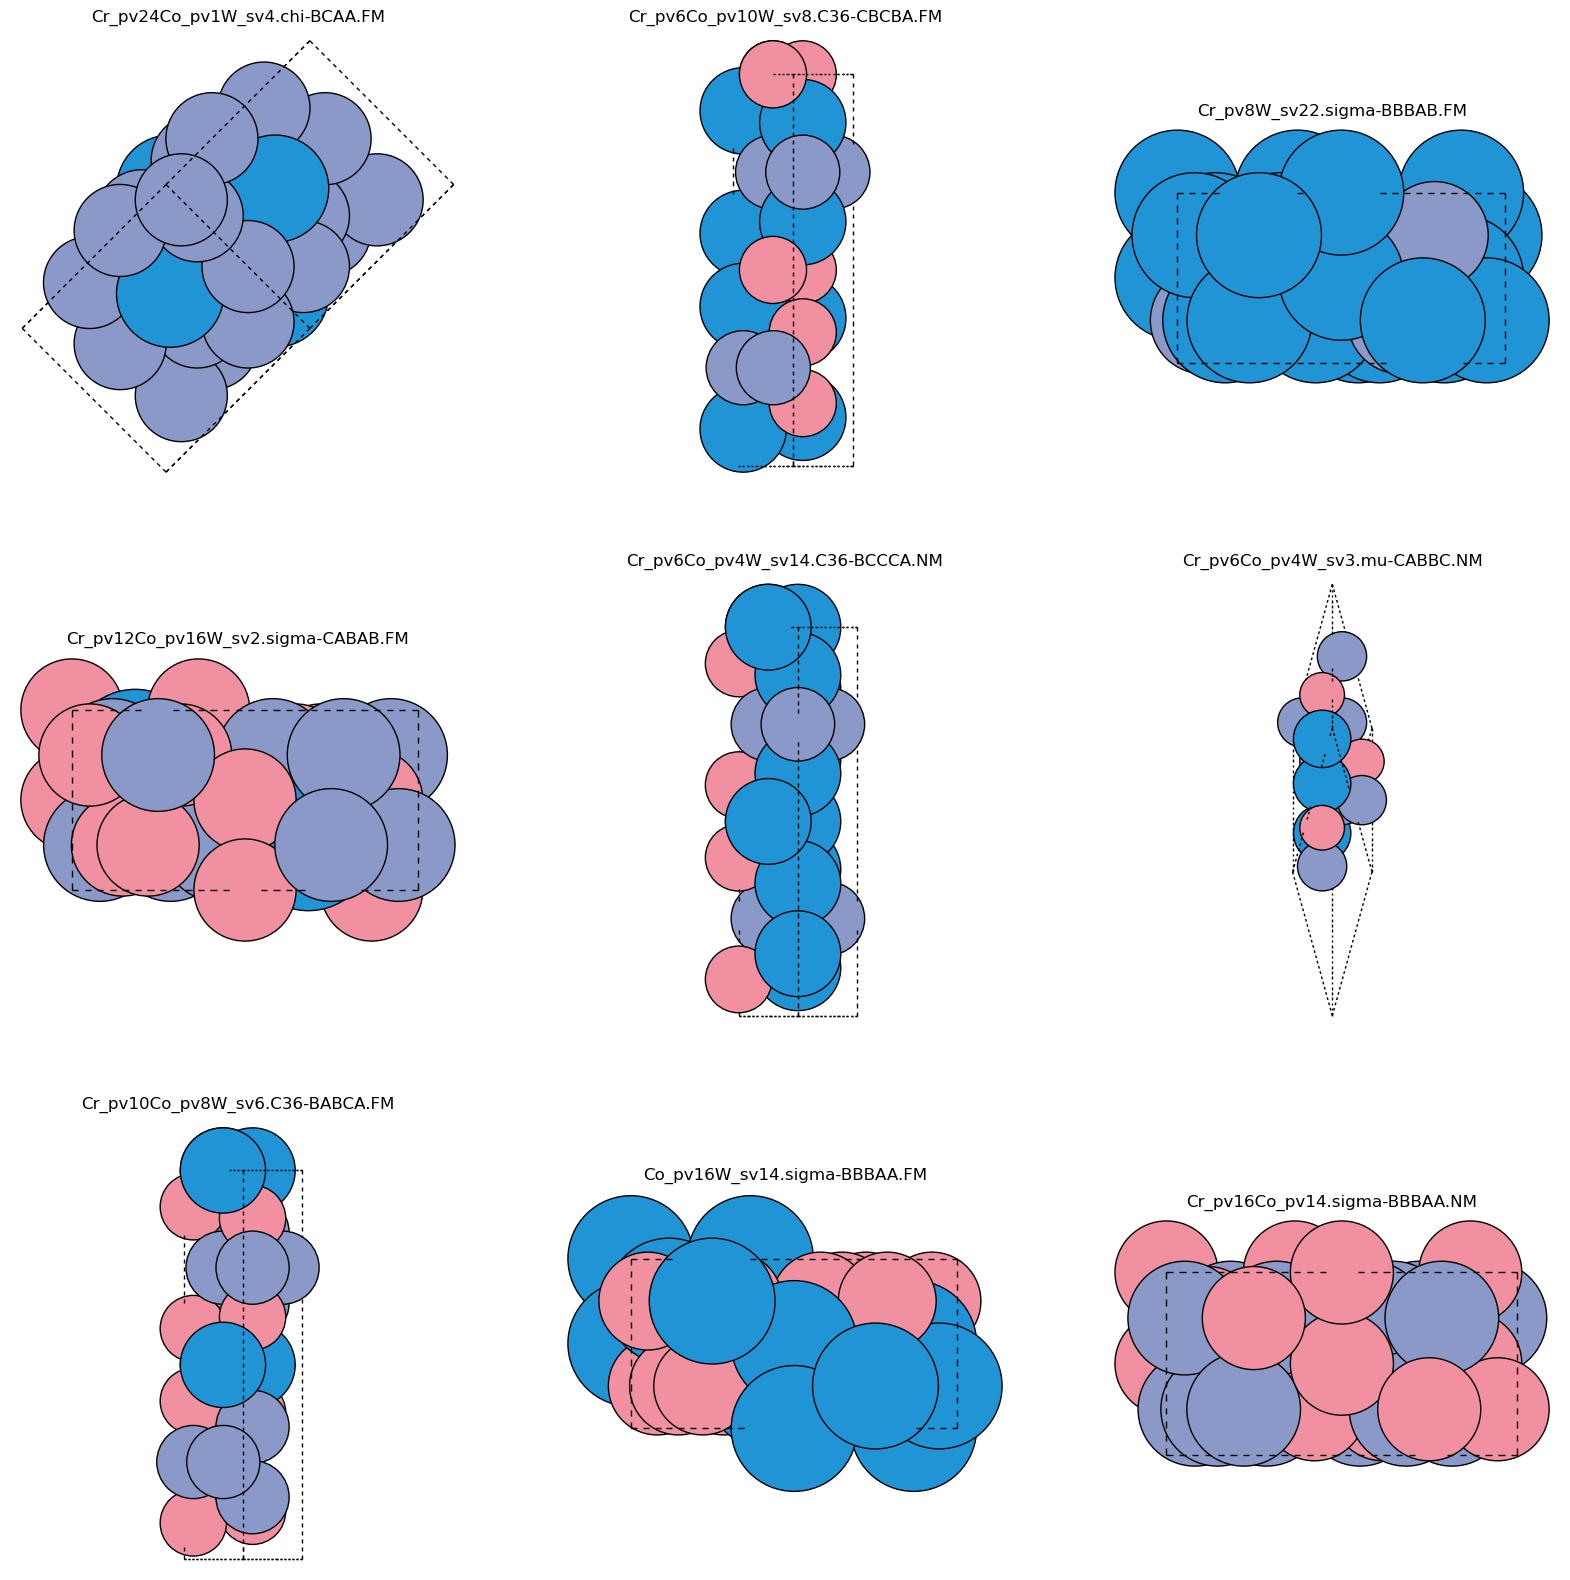

In [21]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, atoms_samples.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation = '90x')
#    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

In [15]:
somesigmas = Atoms_Objects.atoms[Atoms_Objects.index.str.contains('sigma')].sample(n=9)

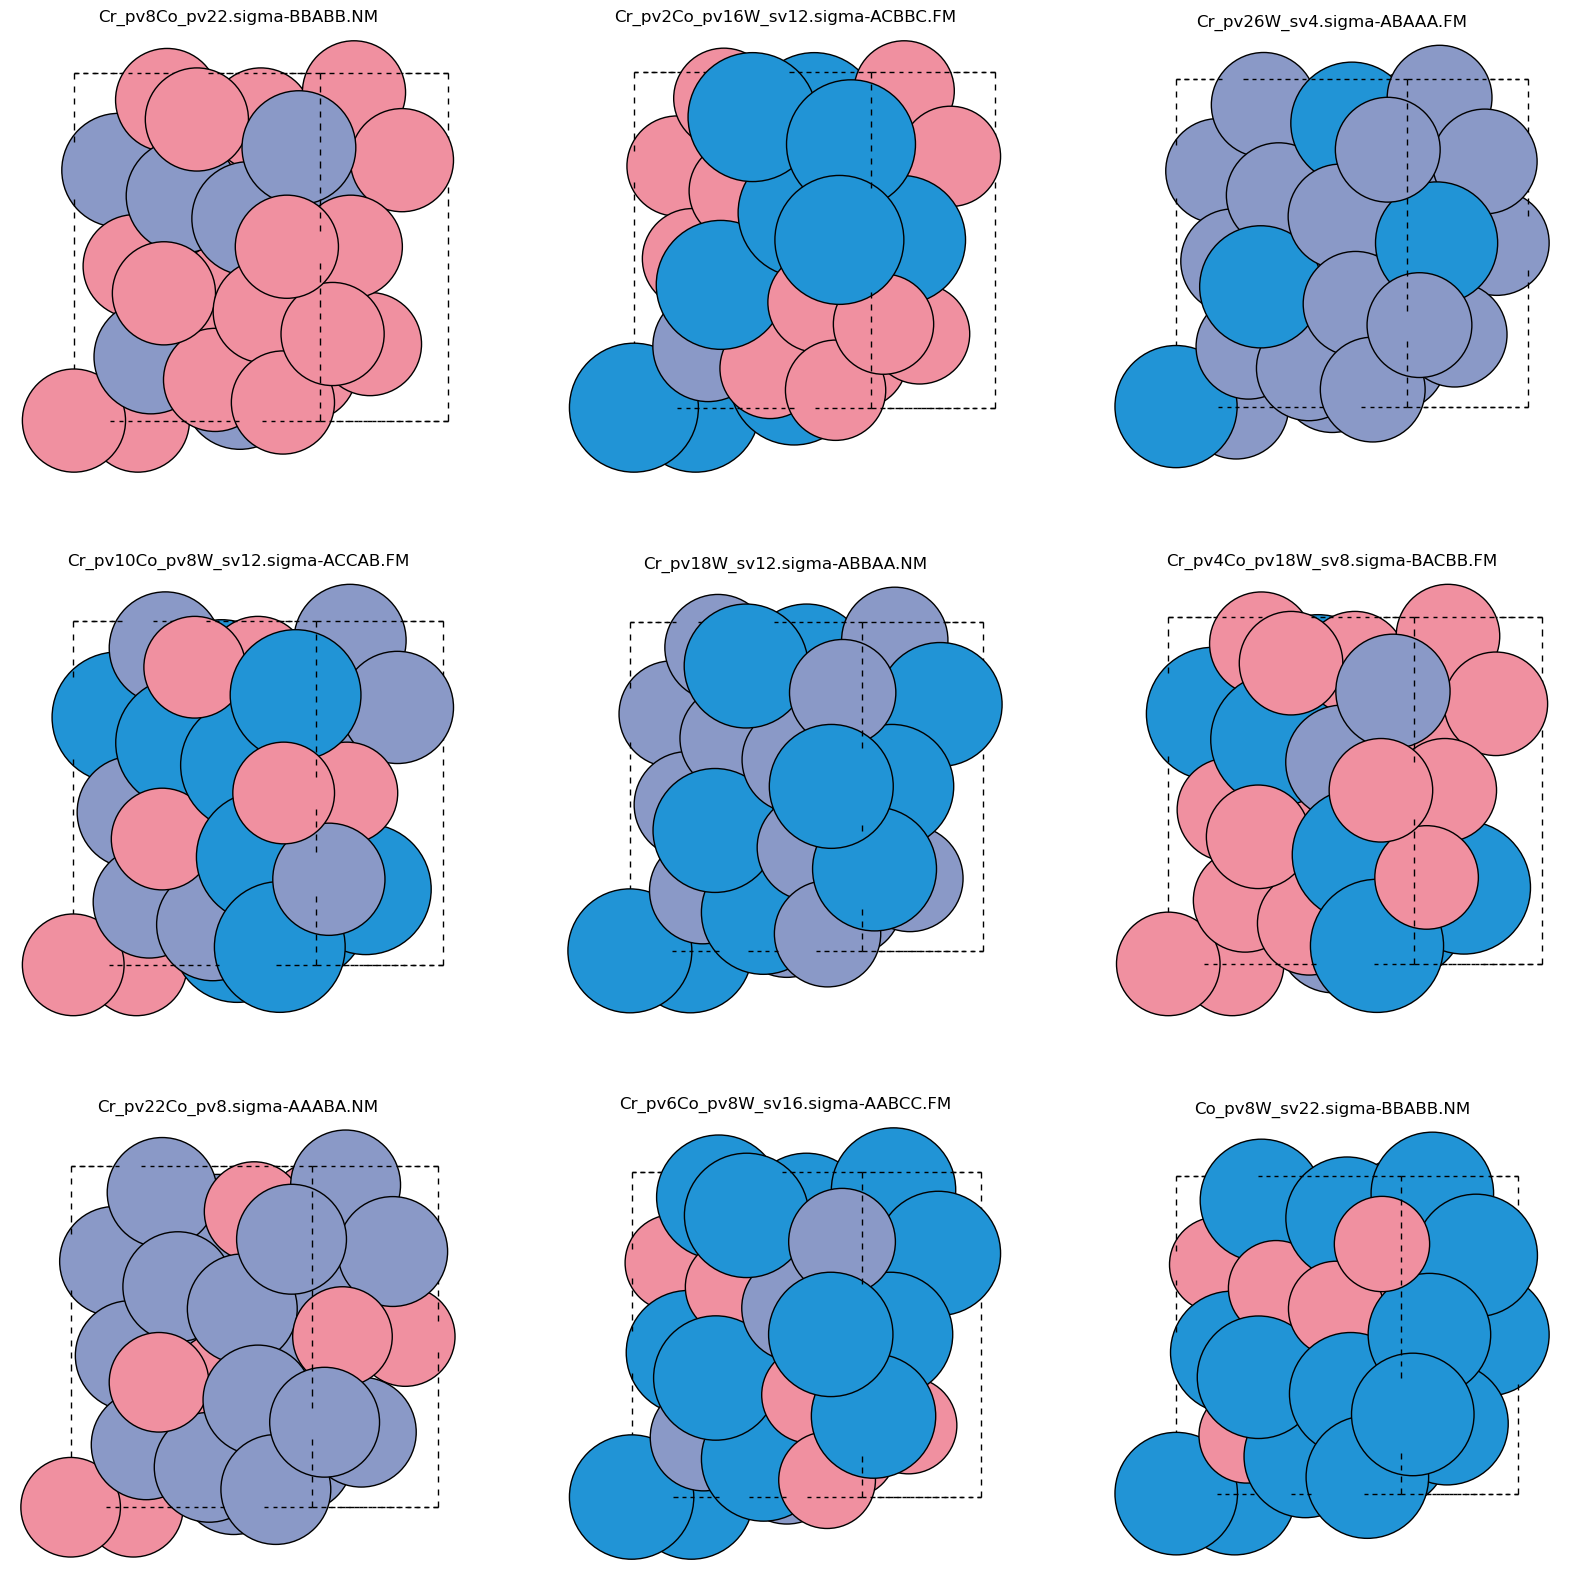

In [16]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, somesigmas.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation='90y, 90x, 45y')
    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

 For the actual visualization of the structures, we should choose one example for each structure and then draw in Vesta or Ovito for good quality figures, including coordination polyhedra etc.